In [2]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,
                        n_redundant=0,n_classes=2,n_clusters_per_class=1,
                        random_state=41,hypercube=False,class_sep=20)

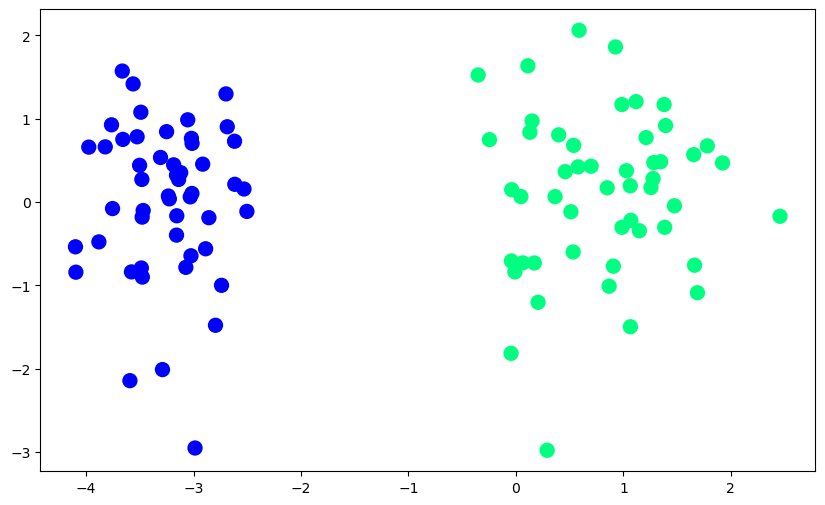

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [7]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

C:\Users\AKASH\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [8]:
m=-(lor.coef_[0][0]/lor.coef_[0][1])
b=-(lor.intercept_/lor.coef_[0][1])

In [11]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input1+b

In [12]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [20]:
def gd(X,y):

    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.5

    for i in range(3000):
        y_hat=sigmoid(np.dot(X,weights))
        weights=weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[0],weights[1:]

In [21]:
intercept,coeff=gd(X,y)

In [22]:
m=-(coeff[0]/coeff[1])
b=-(intercept/coeff[1])

In [23]:
x_input2=np.linspace(-3,3,100)
y_input2=m*x_input2+b

(-3.0, 2.0)

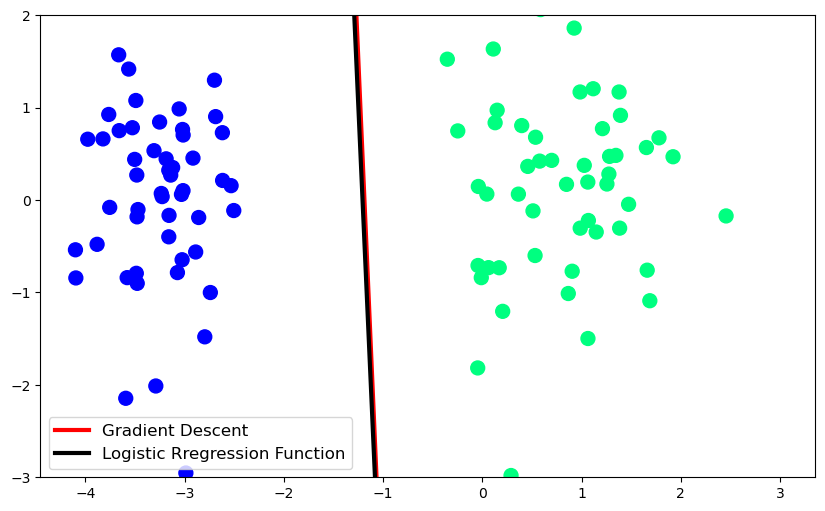

In [24]:
plt.figure(figsize=(10,6))
plt.plot(x_input2,y_input2,color='red',linewidth=3,label="Gradient Descent")
plt.plot(x_input1,y_input1,color='black',linewidth=3,label="Logistic Rregression Function")
plt.legend(loc='best', fontsize=12)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)